# Лабораторная работа 1. Анализ сложности алгоритмов

**Опора:** лекции 1–2.

Реализовать требуется только три функции. Генерация массивов, подсчёт обращений
к элементам, измерение времени и графики уже готовы и лежат в пакете `labkit`
рядом с ноутбуком.

Эксперименты запускаются после того, как пройдены тесты.

In [6]:
import sys
from pathlib import Path

for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "labkit").is_dir():
        sys.path.insert(0, str(candidate))
        break

import labkit as lk

print("Режим:", lk.CONFIG.name, "| размеры массивов:", lk.sizes())

Режим: быстрый | размеры массивов: [10, 100, 1000, 10000]


## Задача 1. Линейный поиск

Найти в массиве позицию заданного значения, просматривая элементы подряд.

- **Вход:** массив целых чисел и искомое значение.
- **Выход:** индекс любого вхождения значения; если значения нет — `-1`.

In [7]:
def linear_search(arr, target):
    """Индекс любого вхождения target в arr или -1, если его нет."""
    # TODO: реализовать линейный поиск
    raise NotImplementedError("linear_search")

In [15]:
def linear_search(arr, target):
    """Индекс любого вхождения target в arr или -1, если его нет."""
    # TODO: реализовать линейный поиск
    length = len(arr)
    for pos in range(length):
        if arr[pos] == target:
            return pos
    else:
        return -1

    raise NotImplementedError("linear_search")

lk.check_search(linear_search, "Линейный поиск")

Линейный поиск
  [ok]   массив длины 0, поиск 5
    Input: {'arr': [], 'target': 5}
    Output: -1
    Expected: -1
  [ok]   массив длины 1, поиск 5
    Input: {'arr': [5], 'target': 5}
    Output: 0
    Expected: {'любой из индексов': [0]}
  [ok]   массив длины 1, поиск 10
    Input: {'arr': [5], 'target': 10}
    Output: -1
    Expected: -1
  [ok]   массив длины 4, поиск 1
    Input: {'arr': [4, 1, 3, 2], 'target': 1}
    Output: 1
    Expected: {'любой из индексов': [1]}
  [ok]   массив длины 4, поиск 4
    Input: {'arr': [4, 1, 3, 2], 'target': 4}
    Output: 0
    Expected: {'любой из индексов': [0]}
  [ok]   массив длины 4, поиск 3
    Input: {'arr': [4, 1, 3, 2], 'target': 3}
    Output: 2
    Expected: {'любой из индексов': [2]}
  [ok]   массив длины 4, поиск 100
    Input: {'arr': [4, 1, 3, 2], 'target': 100}
    Output: -1
    Expected: -1
  [ok]   массив длины 4, поиск -5
    Input: {'arr': [5, -10, 0, -5], 'target': -5}
    Output: 3
    Expected: {'любой из индексов': [3]}

## Задача 2. Двоичный поиск

Решить ту же задачу на массиве, отсортированном по неубыванию, сокращая
рассматриваемый участок вдвое на каждом шаге.

- **Вход:** отсортированный массив целых чисел и искомое значение.
- **Выход:** индекс любого вхождения значения; если значения нет — `-1`.
- **Требование:** за одну итерацию значение из массива читается один раз.

In [16]:
def binary_search(arr, target):
    """Индекс любого вхождения target в отсортированном arr или -1."""
    # TODO: реализовать двоичный поиск
    raise NotImplementedError("binary_search")

In [17]:
def binary_search(arr, target):
    """Индекс любого вхождения target в отсортированном arr или -1."""
    if arr:
        reference = [i for i in range(len(arr))]
        cur = "a"
        ind_cur = -1
        while cur != target:
            ind_cur = (len(reference) - 1)//2
            cur = arr[reference[ind_cur]]
            if cur > target:
                reference = reference[:ind_cur]
            if cur < target:
                reference = reference[ind_cur + 1:]
            if cur == target:
                return reference[ind_cur]
            if not reference:
                return -1
    else:
        return -1
        # TODO: реализовать двоичный поиск
    
        
    raise NotImplementedError("binary_search")

lk.check_search(binary_search, "Двоичный поиск", expect_logarithmic=True)

Двоичный поиск
  [ok]   массив длины 0, поиск 5
    Input: {'arr': [], 'target': 5}
    Output: -1
    Expected: -1
  [ok]   массив длины 1, поиск 5
    Input: {'arr': [5], 'target': 5}
    Output: 0
    Expected: {'любой из индексов': [0]}
  [ok]   массив длины 1, поиск 10
    Input: {'arr': [5], 'target': 10}
    Output: -1
    Expected: -1
  [ok]   массив длины 4, поиск 1
    Input: {'arr': [1, 2, 3, 4], 'target': 1}
    Output: 0
    Expected: {'любой из индексов': [0]}
  [ok]   массив длины 4, поиск 4
    Input: {'arr': [1, 2, 3, 4], 'target': 4}
    Output: 3
    Expected: {'любой из индексов': [3]}
  [ok]   массив длины 4, поиск 3
    Input: {'arr': [1, 2, 3, 4], 'target': 3}
    Output: 2
    Expected: {'любой из индексов': [2]}
  [ok]   массив длины 4, поиск 100
    Input: {'arr': [1, 2, 3, 4], 'target': 100}
    Output: -1
    Expected: -1
  [ok]   массив длины 4, поиск -5
    Input: {'arr': [-10, -5, 0, 5], 'target': -5}
    Output: 1
    Expected: {'любой из индексов': [1]}

## Задача 3. Палиндром

Определить, читается ли строка одинаково слева направо и справа налево.

- **Вход:** строка.
- **Выход:** `True`, если строка — палиндром, иначе `False`.
- **Требования:** решение рекурсивное; циклы и срезы запрещены; сравнение идёт
  с двух концов строки к середине.

```text
Вход:  "level"      Выход: True
Вход:  "algorithm"  Выход: False
Вход:  ""           Выход: True
```

In [18]:
def is_palindrome(text, left=0, right=None):
    """True, если text читается одинаково в обе стороны."""
    # TODO: реализовать рекурсивно, без циклов и срезов
    raise NotImplementedError("is_palindrome")

In [19]:
def is_palindrome(text, left=0, right=None):
    """True, если text читается одинаково в обе стороны."""
    # TODO: реализовать рекурсивно, без циклов и срезов
    if left < len(text):
        if left > len(text)//2:
            return True
        if text[left] == text[-left - 1]:
            return is_palindrome(text, left=(left + 1))
        else:
            return False
    else:
        return True
    raise NotImplementedError("is_palindrome")

lk.check_palindrome(is_palindrome)

Палиндром
  [ok]   проверка палиндрома
    Input: {'text': ''}
    Output: True
    Expected: True
  [ok]   проверка палиндрома
    Input: {'text': 'a'}
    Output: True
    Expected: True
  [ok]   проверка палиндрома
    Input: {'text': 'aa'}
    Output: True
    Expected: True
  [ok]   проверка палиндрома
    Input: {'text': 'ab'}
    Output: False
    Expected: False
  [ok]   проверка палиндрома
    Input: {'text': 'aba'}
    Output: True
    Expected: True
  [ok]   проверка палиндрома
    Input: {'text': 'abba'}
    Output: True
    Expected: True
  [ok]   проверка палиндрома
    Input: {'text': 'abc'}
    Output: False
    Expected: False
  [ok]   проверка палиндрома
    Input: {'text': 'level'}
    Output: True
    Expected: True
  [ok]   проверка палиндрома
    Input: {'text': 'algorithm'}
    Output: False
    Expected: False
  [ok]   проверка палиндрома
    Input: {'text': '123454321'}
    Output: True
    Expected: True
  [ok]   проверка палиндрома
    Input: {'text': '123456

In [20]:
SEARCHES = {"Линейный поиск": linear_search, "Двоичный поиск": binary_search}
search_cases = lk.search_cases_table(SEARCHES)

Поиск: время и обращения:   0%|          | 0/104 [00:00<?, ?опыт/s]

## Эксперимент 1. Неуспешный поиск

Массив содержит `0, …, n−1`, искомое значение — `n`.

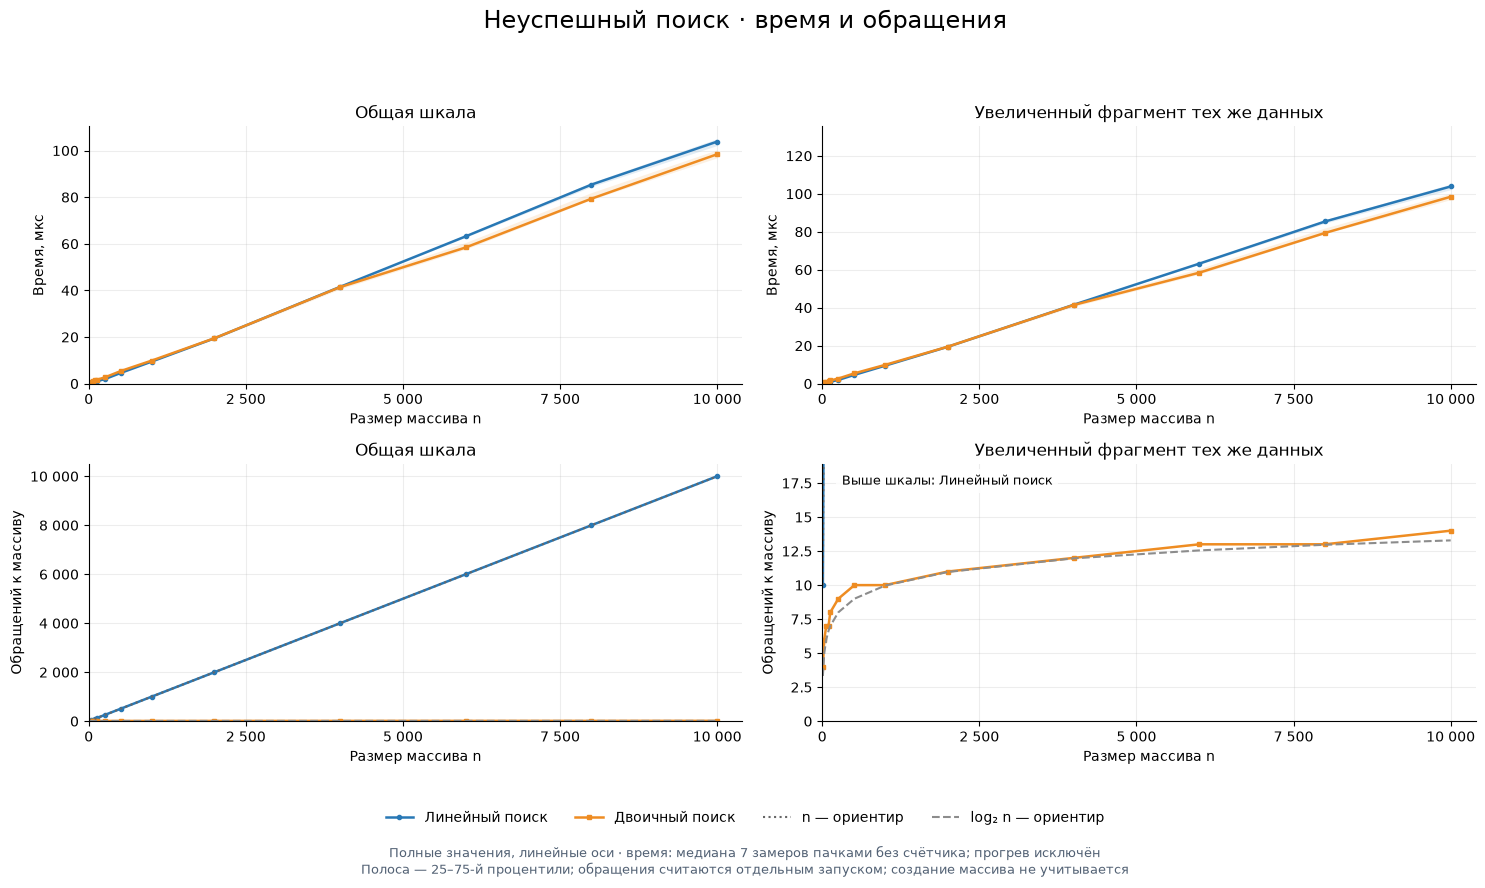

In [21]:
lk.plot_search_overview(search_cases);

## Эксперимент 2. Позиция искомого элемента

Один отсортированный массив, три случая: значение в начале, в середине
и в конце. Середина — индекс `(n−1)//2`. Случай отсутствующего элемента
рассмотрен в предыдущем эксперименте.

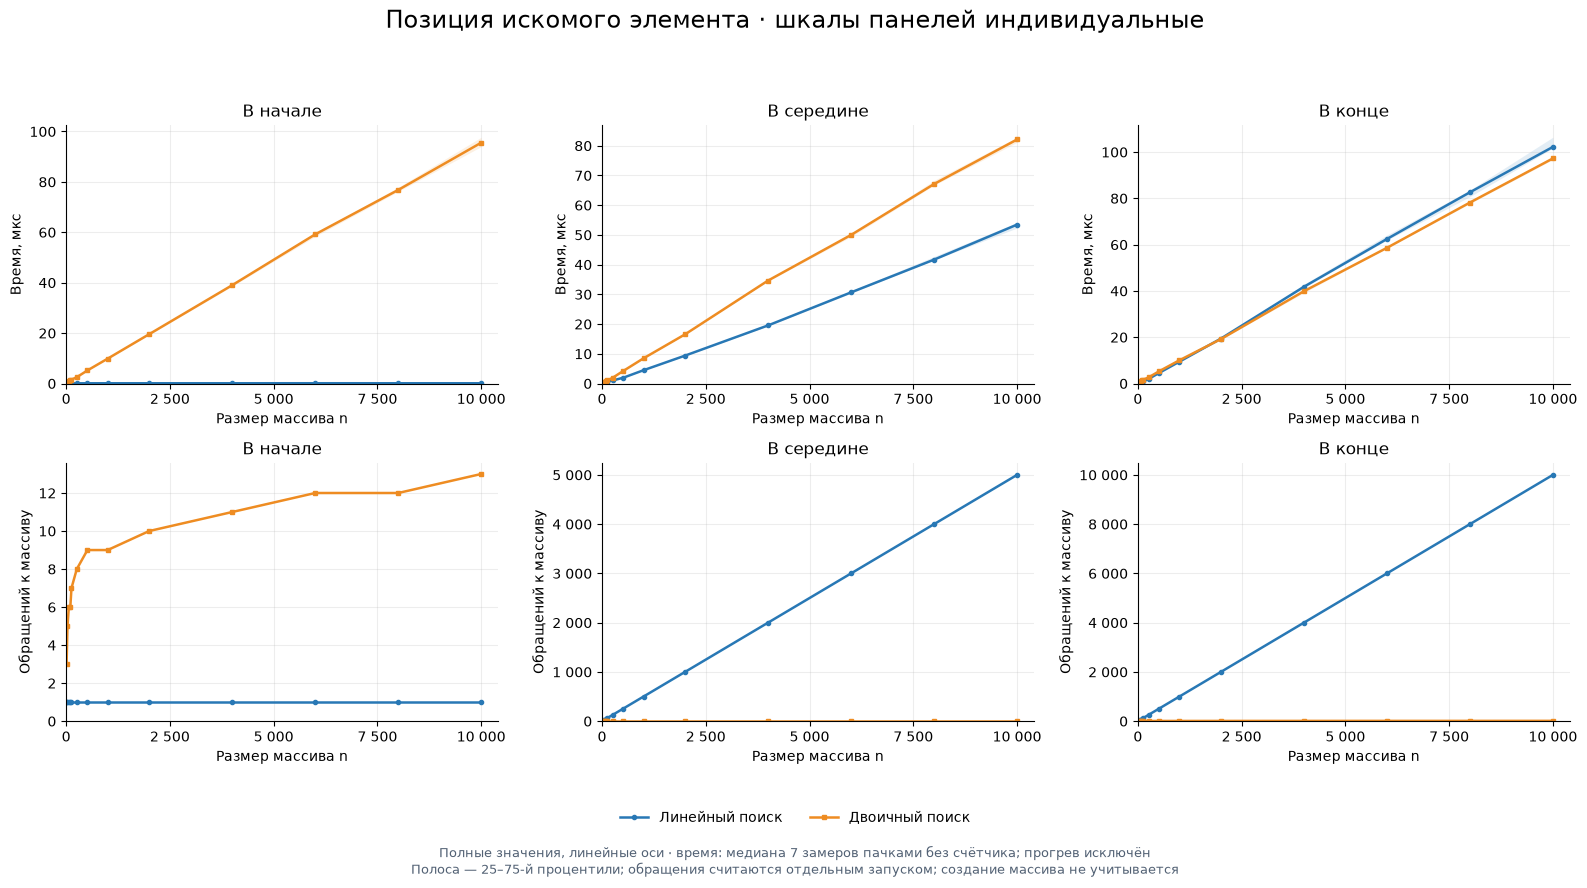

In [22]:
lk.plot_search_positions(search_cases);

## Самостоятельные выводы

1. Почему при расположении цели в начале массива время линейного поиска почти не зависит от размера массива, а двоичный поиск всё равно выполняет несколько шагов?
2. Почему середина массива является особым случаем для двоичного поиска? Всегда ли элемент «в середине» будет найден за первое обращение?
3. Почему случаи «элемент в конце» и «элемент отсутствует» близки для линейного поиска? Чем обработка этих случаев отличается у двоичного поиска?
4. Почему двоичный поиск требует упорядоченных данных? Что именно перестаёт быть верным без этого условия?
5. Каковы базовый случай и рекурсивный переход у проверки палиндрома? Почему каждый переход приближает алгоритм к завершению?